# PDFPlumber Extraction — Quality Evaluation

Measures how accurately pdfplumber captures text from DMP PDFs by comparing
extracted blocks against manually curated reference text files.

**Input (extracted):** `data/output/extracted/sampleN.json`  
**Input (reference):** `data/input/ground_truth/reference_text/sampleN_reference.txt`  
**Output:** per-sample and aggregate quality metrics (no files written)


# PDFPlumber Text Extraction — Evaluation Metrics

> These metrics evaluate the quality of text extracted by `pdfplumber` against manually curated reference files, covering extraction completeness, sequence preservation, noise, and overall similarity.

---

## Metrics at a Glance

| # | Metric | What It Measures |
|---|--------|-----------------|
| 1 | [Word Capture](#1-word-capture) | How much of the reference text was captured |
| 2 | [ROUGE-L](#2-rouge-l) | Sequence and structural similarity via LCS |
| 3 | [Word Precision](#3-word-precision) | How clean the extracted output is |
| 4 | [Word Recall](#4-word-recall) | How much reference content was recovered |
| 5 | [Word F1 Score](#5-word-f1-score) | Balanced precision/recall score |
| 6 | [Extracted Word Count](#6-extracted-word-count) | Total words in extracted text |
| 7 | [Reference Word Count](#7-reference-word-count) | Baseline total from reference text |
| 8 | [Missing Word Count](#8-missing-word-count) | Words in reference but absent from extraction |
| 9 | [Extra Word Count](#9-extra-word-count) | Words in extraction not in reference |

---

## 1. Word Capture

**Measures:** Extraction completeness — how much of the reference text was successfully captured.

$$
\text{Word Capture} = \frac{\text{Matched Reference Words}}{\text{Total Reference Words}}
$$

| Value | Meaning |
|-------|---------|
| `1.000` | All reference words were captured |
| `< 1.000` | Some content is missing |

**Why it matters:** Directly identifies whether information was lost during extraction.

---

## 2. ROUGE-L

**Measures:** Similarity between extracted and reference text using the Longest Common Subsequence (LCS).

$$
\text{ROUGE-L} = \frac{LCS(\text{Extracted}, \text{Reference})}{|\text{Reference}|}
$$

- Higher values → better preservation of text order and structure
- Sensitive to duplicated or reordered content

**Why it matters:** Evaluates reading order and sequence preservation, not just word presence.

---

## 3. Word Precision

**Measures:** The proportion of extracted words that are correct — i.e., extraction cleanliness.

$$
\text{Precision} = \frac{\text{Correct Words}}{\text{Correct Words} + \text{Extra Words}}
$$

- High precision → low noise, few spurious or duplicated words

**Why it matters:** Penalises over-extraction, duplicated content, and OCR artifacts.

---

## 4. Word Recall

**Measures:** The proportion of reference words successfully recovered from the extraction.

$$
\text{Recall} = \frac{\text{Correct Words}}{\text{Correct Words} + \text{Missing Words}}
$$

- High recall → fewer missing words, more complete extraction

**Why it matters:** Evaluates preservation of important content from the source document.

---

## 5. Word F1 Score

**Measures:** A balanced combination of precision and recall.

$$
F_1 = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

A high F1 score indicates both low missing content **and** low extraction noise simultaneously.

**Why it matters:** Provides a single overall quality score that doesn't reward trading one for the other.

---

## 6. Extracted Word Count

**Measures:** Total number of words in the extracted output.

Unusually large values may indicate:
- Duplicated words or phrases
- Repeated headers or footers
- Extraction noise from non-content regions

**Why it matters:** Useful for spotting over-extraction before diving into precision/recall.

---

## 7. Reference Word Count

**Measures:** Total number of words in the manually curated reference text.

**Why it matters:** Serves as the baseline denominator for all completeness and recall calculations.

---

## 8. Missing Word Count

**Measures:** Words present in the reference but absent from the extraction.

$$
\text{Missing Words} = \text{Reference Words} - \text{Extracted Words}
$$

Higher values indicate extraction failures or lost content regions.

**Why it matters:** Directly quantifies information loss.

---

## 9. Extra Word Count

**Measures:** Words present in the extraction that do not exist in the reference.

$$
\text{Extra Words} = \text{Extracted Words} - \text{Reference Words}
$$

Higher values may indicate:
- Duplicated content
- Extraction noise
- OCR artifacts or spurious characters

**Why it matters:** Directly quantifies extraction pollution and duplication errors.

---

## Summary

Together, these nine metrics provide a comprehensive view of PDF text extraction quality across five dimensions:

| Dimension | Relevant Metrics |
|-----------|-----------------|
| **Completeness** | Word Capture, Word Recall, Missing Word Count |
| **Cleanliness** | Word Precision, Extra Word Count |
| **Overall quality** | Word F1 Score |
| **Structural fidelity** | ROUGE-L |
| **Volume diagnostics** | Extracted Word Count, Reference Word Count |

> These metrics were developed to evaluate `pdfplumber` for extracting machine-readable text from Data Management Plan (DMP) PDFs within the **DMPBridge** project.


## 1 — Imports and metric functions

In [1]:
import json
import re
from collections import Counter
from difflib import SequenceMatcher
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

sns.set_theme(style="ticks")
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "figure.dpi": 110, "axes.titlesize": 12})

_ROOT   = Path.cwd() if (Path.cwd() / "dmpbridge").exists() else Path.cwd().parent
EXT_DIR = _ROOT / "data/output/extracted"
REF_DIR = _ROOT / "data/input/ground_truth/reference_text"

print("Extracted blocks :", EXT_DIR, "exists:", EXT_DIR.exists())
print("Reference text   :", REF_DIR, "exists:", REF_DIR.exists())


def _tokens(text):
    return re.sub(r"[^a-z0-9]", " ", text.lower()).split()


def evaluate(extracted_text, reference_text):
    ext = _tokens(extracted_text)
    ref = _tokens(reference_text)
    ext_c = Counter(ext)
    ref_c = Counter(ref)
    correct = sum((ext_c & ref_c).values())
    missing = sum(ref_c.values()) - correct
    extra   = sum(ext_c.values()) - correct
    precision    = correct / (correct + extra)   if (correct + extra)   else 0.0
    recall       = correct / (correct + missing) if (correct + missing) else 0.0
    f1           = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    word_capture = correct / sum(ref_c.values()) if ref_c else 0.0
    lcs     = sum(b.size for b in SequenceMatcher(None, ext, ref).get_matching_blocks())
    rouge_l = lcs / len(ref) if ref else 0.0
    return {
        "word_capture":    round(word_capture, 4),
        "rouge_l":         round(rouge_l, 4),
        "precision":       round(precision, 4),
        "recall":          round(recall, 4),
        "f1":              round(f1, 4),
        "extracted_words": len(ext),
        "reference_words": len(ref),
        "missing_words":   missing,
        "extra_words":     extra,
    }


Extracted blocks : C:\Users\Nahid\dmpbridge\data\output\extracted exists: True
Reference text   : C:\Users\Nahid\dmpbridge\data\input\ground_truth\reference_text exists: True


## 2 — Run evaluation on all 10 samples

In [2]:
SCORE_COLS = ["word_capture", "rouge_l", "precision", "recall", "f1"]
COUNT_COLS = ["extracted_words", "reference_words", "missing_words", "extra_words"]

def _snum(fp): return int(fp.stem.replace('sample', ''))

ext_files = sorted(EXT_DIR.glob('sample*.json'), key=_snum)
results   = []

for ef in ext_files:
    stem = ef.stem
    rf   = REF_DIR / f'{stem}_reference.txt'
    if not rf.exists():
        print(f'  missing reference: {rf.name}')
        continue
    blocks   = json.loads(ef.read_text(encoding='utf-8'))
    ext_text = ' '.join(b['text'] for b in blocks)
    ref_text = rf.read_text(encoding='utf-8')
    m = evaluate(ext_text, ref_text)
    m['sample'] = stem
    results.append(m)
    print(f"  {stem}: F1={m['f1']:.3f}  capture={m['word_capture']:.3f}  "
          f"ROUGE-L={m['rouge_l']:.3f}  missing={m['missing_words']}  extra={m['extra_words']}")

df = pd.DataFrame(results).set_index('sample')
print()
display(
    df[SCORE_COLS + COUNT_COLS]
    .style.format({c: '{:.3f}' for c in SCORE_COLS})
    .background_gradient(subset=SCORE_COLS, cmap='RdYlGn', vmin=0.8, vmax=1.0)
)


  sample1: F1=1.000  capture=0.999  ROUGE-L=0.999  missing=1  extra=0
  sample2: F1=0.999  capture=0.999  ROUGE-L=0.999  missing=3  extra=1
  sample3: F1=1.000  capture=1.000  ROUGE-L=1.000  missing=0  extra=0
  sample4: F1=0.999  capture=0.999  ROUGE-L=0.999  missing=1  extra=2
  sample5: F1=0.999  capture=0.999  ROUGE-L=0.999  missing=1  extra=2
  sample6: F1=0.995  capture=0.997  ROUGE-L=0.997  missing=1  extra=2
  sample7: F1=1.000  capture=1.000  ROUGE-L=1.000  missing=0  extra=0
  sample8: F1=0.999  capture=0.999  ROUGE-L=0.999  missing=1  extra=0
  sample9: F1=0.998  capture=0.997  ROUGE-L=0.997  missing=3  extra=2
  sample10: F1=0.994  capture=0.992  ROUGE-L=0.992  missing=7  extra=3



,word_capture,rouge_l,precision,recall,f1,extracted_words,reference_words,missing_words,extra_words
sample,,,,,,,,,
sample1,0.999,0.999,1.000,0.999,1.000,1005,1006,1,0
sample2,0.999,0.999,1.000,0.999,0.999,2176,2178,3,1
sample3,1.000,1.000,1.000,1.000,1.000,854,854,0,0
sample4,0.999,0.999,0.998,0.999,0.999,1023,1022,1,2
sample5,0.999,0.999,0.998,0.999,0.999,1086,1085,1,2
sample6,0.997,0.997,0.993,0.997,0.995,289,288,1,2
sample7,1.000,1.000,1.000,1.000,1.000,262,262,0,0
sample8,0.999,0.999,1.000,0.999,0.999,836,837,1,0
sample9,0.997,0.997,0.998,0.997,0.998,1125,1126,3,2


## 3 — Score overview

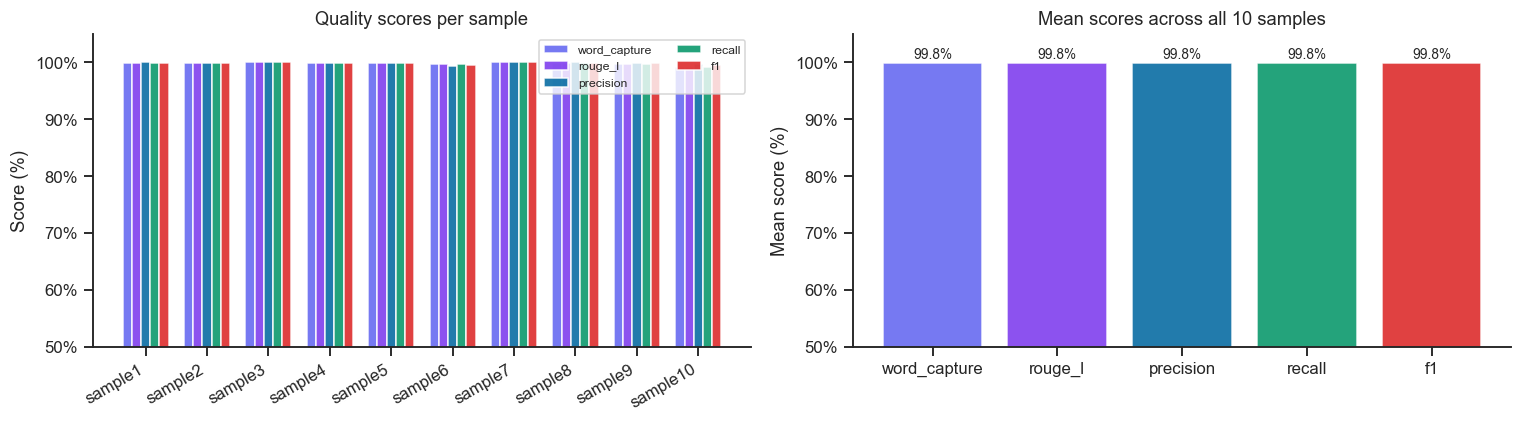

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ["#6366f1", "#7c3aed", "#0369a1", "#059669", "#dc2626"]
w = 0.15
x = range(len(df))

for j, (col, color) in enumerate(zip(SCORE_COLS, colors)):
    axes[0].bar([xi + j * w for xi in x], df[col] * 100,
                width=w, label=col, color=color, edgecolor='white', alpha=0.88)
axes[0].set_xticks([xi + w * 2 for xi in x])
axes[0].set_xticklabels(df.index, rotation=30, ha='right')
axes[0].set_ylim(50, 105)
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Quality scores per sample')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
axes[0].legend(fontsize=8, ncol=2)
sns.despine(ax=axes[0])

means = df[SCORE_COLS].mean() * 100
bars = axes[1].bar(means.index, means, color=colors, edgecolor='white', alpha=0.88)
for bar, v in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_ylim(50, 105)
axes[1].set_ylabel('Mean score (%)')
axes[1].set_title('Mean scores across all 10 samples')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()


## 4 — Word count comparison

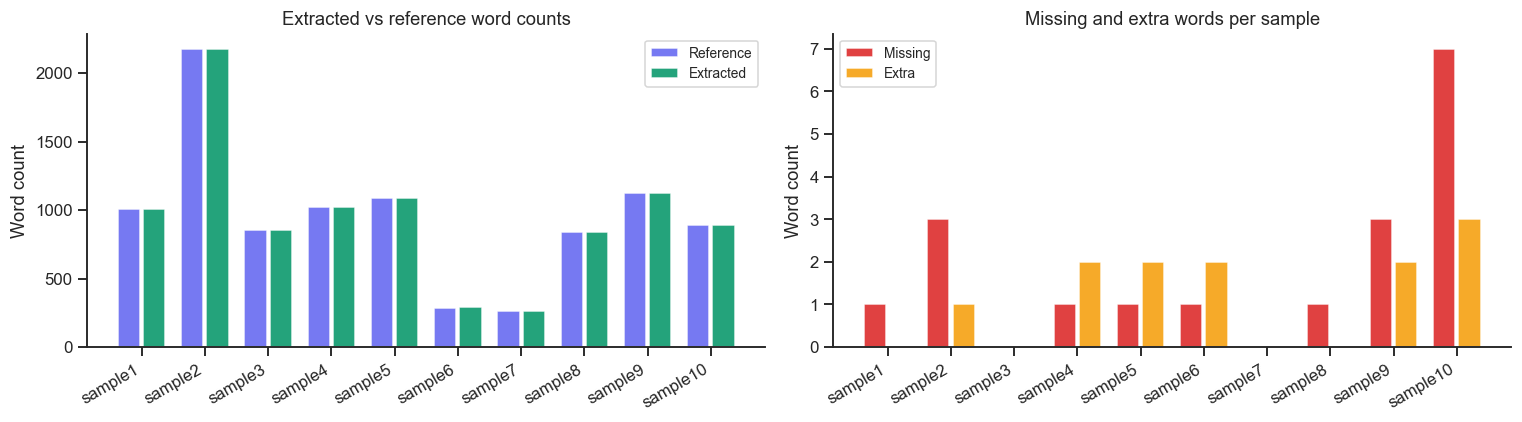

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
x    = range(len(df))
lbls = df.index.tolist()

axes[0].bar([xi - 0.2 for xi in x], df['reference_words'], 0.35,
            label='Reference', color='#6366f1', edgecolor='white', alpha=0.88)
axes[0].bar([xi + 0.2 for xi in x], df['extracted_words'], 0.35,
            label='Extracted', color='#059669', edgecolor='white', alpha=0.88)
axes[0].set_xticks(x); axes[0].set_xticklabels(lbls, rotation=30, ha='right')
axes[0].set_ylabel('Word count')
axes[0].set_title('Extracted vs reference word counts')
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

axes[1].bar([xi - 0.2 for xi in x], df['missing_words'], 0.35,
            label='Missing', color='#dc2626', edgecolor='white', alpha=0.88)
axes[1].bar([xi + 0.2 for xi in x], df['extra_words'],   0.35,
            label='Extra',   color='#f59e0b', edgecolor='white', alpha=0.88)
axes[1].set_xticks(x); axes[1].set_xticklabels(lbls, rotation=30, ha='right')
axes[1].set_ylabel('Word count')
axes[1].set_title('Missing and extra words per sample')
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()


## 5 — Aggregate summary

In [5]:
agg = df[SCORE_COLS].agg(['mean', 'min', 'max'])
print('Aggregate quality scores across all 10 samples:\n')
print(f"  {'Metric':<16} {'Mean':>8} {'Min':>8} {'Max':>8}")
print('  ' + '-' * 44)
for col in SCORE_COLS:
    print(f"  {col:<16} {agg.loc['mean', col]:>7.1%}  {agg.loc['min', col]:>7.1%}  {agg.loc['max', col]:>7.1%}")

total_ref  = df['reference_words'].sum()
total_ext  = df['extracted_words'].sum()
total_miss = df['missing_words'].sum()
total_xtra = df['extra_words'].sum()
print(f'\n  Total reference words : {total_ref:,}')
print(f'  Total extracted words : {total_ext:,}')
print(f'  Total missing words   : {total_miss:,}  ({total_miss/total_ref:.1%} of reference)')
print(f'  Total extra words     : {total_xtra:,}  ({total_xtra/total_ext:.1%} of extracted)')


Aggregate quality scores across all 10 samples:

  Metric               Mean      Min      Max
  --------------------------------------------
  word_capture       99.8%    99.2%   100.0%
  rouge_l            99.8%    99.2%   100.0%
  precision          99.8%    99.3%   100.0%
  recall             99.8%    99.2%   100.0%
  f1                 99.8%    99.4%   100.0%

  Total reference words : 9,552
  Total extracted words : 9,546
  Total missing words   : 18  (0.2% of reference)
  Total extra words     : 12  (0.1% of extracted)
